# Nepal Climate Risk & Resilience Assessment
### District-level risk index, validation against disaster history, and a USD 100M investment recommendation

**Central question (from the brief):**
> *How do climate hazards, terrain, population exposure, infrastructure, and access/vulnerability interact to create risk across Nepal's 77 districts, and what does Nepal's own historical disaster record indicate about where that risk has materialized?*

---

## How to read this notebook

Every step follows the same pattern, so you always know *why* the code exists:

| Label | Meaning |
|---|---|
| **Concept** | The idea in plain language, for someone new to the topic |
| **What we do** | What the next code cell actually computes |
| **Decision** | A judgment call the brief asks us to make and justify |
| **Finding** | What the result means, written after looking at the output |
| **How to say it** | One or two sentences you can use when presenting |

### The big idea in one paragraph
Disaster professionals describe risk with a simple equation:

$$\text{Risk} = \text{Hazard} \times \text{Exposure} \times \text{Vulnerability}$$

- **Hazard**: how likely and how strong the dangerous event is (heavy rain, steep unstable slopes, big rivers).
- **Exposure**: what is in harm's way (people, hospitals, schools, hydropower plants).
- **Vulnerability**: how badly those people and assets would suffer, and how hard it is to help them (few roads, few hospitals).

A huge landslide on an empty mountainside is *hazard without exposure*, so low risk. A city with no hazard is *exposure without hazard*, so low risk. Risk is high only where **all three** meet. That is the whole project: measure the three pieces for each district, combine them, and then **check against real disasters** whether our measurement makes sense.

### Roadmap (matches the brief's 8 phases)
0. Load data and read the data dictionary limitations
1. Climate record: has rainfall changed?
2. Terrain & rivers: physical hazard
3. Exposure: people & infrastructure
4. Vulnerability: access & health capacity
5. Composite risk score
6. **Validation** against 12,518 recorded disasters (the most important phase)
7. USD 100M investment recommendation
8. Outputs for the presentation

---
# Phase 0: Setup and data loading

**Concept: libraries.** Python on its own is basic; *libraries* add tools.
- `pandas`: tables (called *DataFrames*), like Excel inside Python.
- `numpy`: fast maths on columns of numbers.
- `matplotlib`: charts.
- `scipy.stats`: statistics (trend lines, correlations).
- `statsmodels`: regression models with full statistical output.

**What we do:** import the libraries, set up an output folder, and define two helper functions we will reuse many times.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.spines.top": False, "axes.spines.right": False})

DATA = "nepal_climate_capstone_student_data"
OUT = "outputs"
FIG = os.path.join(OUT, "figures")
os.makedirs(FIG, exist_ok=True)


def minmax(s):
    # Min-max normalization from the brief: lowest district -> 0, highest -> 100.
    return (s - s.min()) / (s.max() - s.min()) * 100


def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, name), dpi=150, bbox_inches="tight")
    plt.show()

**Concept: min-max normalization.** Population is counted in hundreds of thousands, hydropower in megawatts, hospitals in single digits. You cannot add those directly; it would be like adding kilograms to kilometres. Min-max rescales every variable to the same 0–100 ruler:

$$\text{Score} = \frac{x - \min}{\max - \min} \times 100$$

The lowest district gets 0, the highest gets 100, everyone else falls in between. Note that a score is **relative**: 0 means "lowest in Nepal", not "no risk at all".

### Load the four files

In [2]:
climate = pd.read_csv(f"{DATA}/climate_hazard.csv", parse_dates=["date"])
expo = pd.read_csv(f"{DATA}/exposure_vulnerability.csv")
events = pd.read_csv(f"{DATA}/disaster_events.csv", parse_dates=["incident_date"])
clusters = pd.read_csv(f"{DATA}/climate_grid_clusters.csv")
dictionary = pd.read_csv(f"{DATA}/data_dictionary.csv")

for name, df in [("climate", climate), ("exposure", expo), ("events", events), ("clusters", clusters)]:
    print(f"{name:9s} rows={len(df):>9,}  columns={df.shape[1]}")
print("climate date range:", climate.date.min().date(), "->", climate.date.max().date())
print("events  date range:", events.incident_date.min().date(), "->", events.incident_date.max().date())

climate   rows=1,031,107  columns=14
exposure  rows=       77  columns=32
events    rows=   12,518  columns=19
clusters  rows=       77  columns=3
climate date range: 1990-01-01 -> 2026-08-30
events  date range: 2011-05-09 -> 2026-09-05


### Checkpoint: read the data dictionary limitations
The brief insists we read every limitation **before** using a column. Below is every column that carries a caveat. These caveats drive several decisions later on.

In [3]:
caveats = dictionary.dropna(subset=["caveats_limitations"])[["file", "column", "caveats_limitations"]]
with pd.option_context("display.max_colwidth", 160):
    display(caveats)

,file,column,caveats_limitations
0,climate_hazard.csv,date,Full range 1990-01-01 to 2026-08-30. See rainfall_mm caveat: trend/anomaly analysis should be restricted to 2004 onward.
2,climate_hazard.csv,latitude,"One point per district, not a grid -- a simplification for a country this size"
3,climate_hazard.csv,longitude,Same as above
4,climate_hazard.csv,rainfall_mm,TWO VERIFIED LIMITATIONS. (1) Grid resolution: 52 of 77 districts share a byte-identical daily rainfall series with at least one neighboring district (NASA ...
12,climate_hazard.csv,rainfall_anomaly_pct,"Uses a flat all-time mean, not a seasonal baseline -- every dry-season day shows close to -100%; this is a crude signal, not a true seasonal anomaly. Also s..."
13,climate_hazard.csv,elevation_m,Join to exposure_vulnerability.csv (elevation_mean_m) yourself if needed for analysis
14,exposure_vulnerability.csv,district_id,"Use this to join files, not district_name text"
15,exposure_vulnerability.csv,district_name,"NOTE: Rukum East/Rukum West are spelled this way here, but as EASTERN RUKUM / WESTERN RUKUM in climate_hazard.csv and disaster_events.csv. Apply an explicit..."
20,exposure_vulnerability.csv,elevation_std_m,"VERIFIED RELIABLE. Recommended as the primary terrain-ruggedness variable -- unaffected by the slope calculation bug below, and confirmed to produce physica..."
21,exposure_vulnerability.csv,slope_mean_deg,"VERIFIED BUG, NOT FIXED IN THIS FILE (raw DEM not available to recompute). Values are saturated near 90 degrees for nearly all districts (mean 89.5, std 0.9..."


**The caveats that change our analysis (summary):**

| Caveat | What we do about it |
|---|---|
| Only **45 independent** rainfall series across 77 districts (NASA grid is coarse) | National climate statistics use one district per cluster, so the same series is not counted twice |
| Rainfall roughly **doubles in 2004**: a data-source change, not real climate | Trends and anomalies use **2004 onward only** |
| `slope_*` columns are broken (saturated near 90°) | **Never used**; `elevation_std_m` measures ruggedness instead |
| Rukum is spelled `RUKUM EAST/WEST` in one file and `EASTERN/WESTERN RUKUM` in the others | Apply a name alias before joining |
| Hospitals, schools and roads come from OpenStreetMap, which undercounts rural areas | Named as a limitation in Phase 4 |
| `people_affected` is 0 for every event | Not used; we validate with event counts and deaths |
| Household size is a national constant (4.37) | `households_estimated` not used (it adds no district information) |

### Fix the Rukum naming so tables join correctly
**Concept: joining.** Joining (merging) two tables means matching rows that refer to the same thing, here the same district. If one table says `RUKUM EAST` and another says `EASTERN RUKUM`, the computer treats them as different districts and silently drops them. We translate the names first.

In [4]:
ALIAS = {"EASTERN RUKUM": "RUKUM EAST", "WESTERN RUKUM": "RUKUM WEST"}
for df in (climate, events, clusters):
    df["district_name"] = df["district_name"].replace(ALIAS)
expo["district_name"] = expo["district_name"].str.upper()

# Every file should now contain the same 77 names.
names = set(expo.district_name)
for label, df in [("climate", climate), ("events", events), ("clusters", clusters)]:
    print(f"{label:8s} unmatched names: {set(df.district_name) ^ names or 'none'}")

climate  unmatched names: none
events   unmatched names: none
clusters unmatched names: none


---
# Phase 1: The climate record

**Goal:** has Nepal's rainfall changed, and what counts as "extreme" rain in each district?

### Step 1.0: Why we cannot use 1990–2003
Before computing anything, look at the raw national average. If the instrument changes, the numbers jump even when the weather does not.

independent climate series: 45


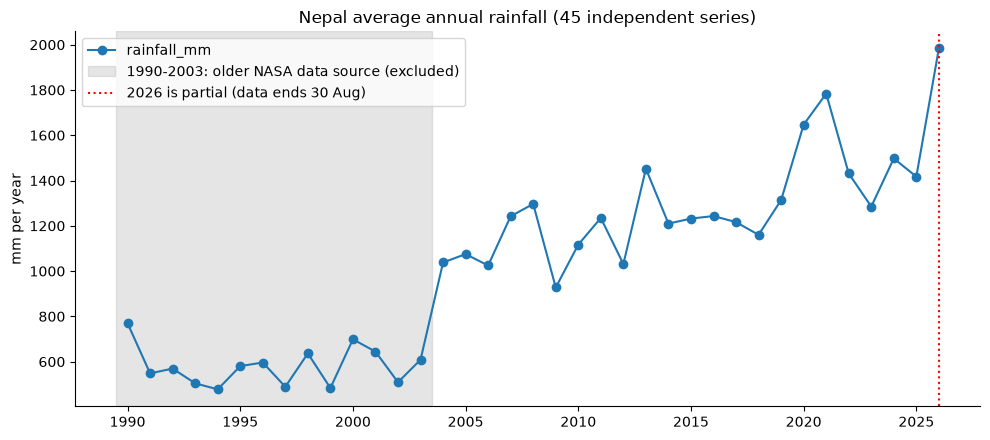

2.03 x jump between periods


In [5]:
# One representative district per climate cluster, so the 45 independent series count once each.
indep = clusters.drop_duplicates("climate_grid_cluster").district_name
clim_indep = climate[climate.district_name.isin(indep)]
print("independent climate series:", clim_indep.district_name.nunique())

daily_nat = clim_indep.groupby("date").rainfall_mm.mean()
annual_nat = daily_nat.groupby(daily_nat.index.year).mean() * 365   # mean mm/day -> mm/year

ax = annual_nat.plot(marker="o")
ax.axvspan(1989.5, 2003.5, color="grey", alpha=0.2, label="1990-2003: older NASA data source (excluded)")
ax.axvline(2026, color="red", ls=":", label="2026 is partial (data ends 30 Aug)")
ax.set(title="Nepal average annual rainfall (45 independent series)", ylabel="mm per year", xlabel="")
ax.legend()
savefig("01_structural_break.png")
print((annual_nat.loc[2004:2019].mean() / annual_nat.loc[1990:2003].mean()).round(2), "x jump between periods")

**Finding:** rainfall roughly doubles in a single step at 2004. Real climate does not do that; the data source changed (reanalysis-only to satellite-blended). If we compared 1990s against 2020s we would "discover" a dramatic change that is entirely artificial.

**Decision: analysis window = 2004–2025.**
- 2004 start: excludes the structural break, as the data dictionary instructs.
- 2025 end for annual totals: 2026 stops on 30 August. A partial year is missing its dry months, so its total looks artificially low and its daily average artificially high. 2026 is examined separately at the end of this phase.

**How to say it:** *"The raw satellite record shows rainfall doubling in 2004. That's an instrument change, not climate change, so all trend analysis starts in 2004."*

### Step 1.1: Define an "extreme rainfall day"

**Concept: percentiles.** Sort all of a district's rainy days from lightest to heaviest. The **95th percentile (P95)** is the value that 95% of rainy days fall below. A day above P95 is in the heaviest 5%, which is our definition of *extreme*.

**Why district-specific?** 40 mm might be ordinary in wet eastern hills but extraordinary in dry Mustang. Local infrastructure and soils are adapted to local "normal", so extreme is relative to the place.

**Why also a Nepal-wide threshold?** If every district's threshold is its own P95, every district has roughly the same number of extreme days by construction (5% of rainy days). That's useful for *trends*, but useless for *comparing* districts. To compare districts we also count days above **one national threshold**, the same ruler for everyone.

**Decision details:**
- *Rainy day* = at least 1 mm (a standard meteorological convention). Including dry days would put P95 at a trivially low value in the dry season.
- Thresholds computed on **2004–2025**. The data dictionary allows the full record for thresholds, but because pre-2004 values are about half as large, mixing the two regimes would pull thresholds down and inflate later extreme-day counts. Using one consistent regime is safer.

In [6]:
WET = 1.0
win = climate[(climate.date.dt.year >= 2004) & (climate.date.dt.year <= 2025)].copy()
win["year"] = win.date.dt.year

# District thresholds: P95 of that district's own rainy days.
p95 = win[win.rainfall_mm >= WET].groupby("district_name").rainfall_mm.quantile(0.95).rename("p95_mm")

# National threshold: P95 of all rainy days pooled across the 45 independent series.
win_indep = win[win.district_name.isin(indep)]
NAT_P95 = win_indep.loc[win_indep.rainfall_mm >= WET, "rainfall_mm"].quantile(0.95)
print(f"Nepal-wide P95 threshold: {NAT_P95:.1f} mm/day")

win = win.join(p95, on="district_name")
win["extreme_local"] = win.rainfall_mm > win.p95_mm
win["extreme_national"] = win.rainfall_mm > NAT_P95

thr = p95.to_frame()
thr["deviation_from_national_mm"] = thr.p95_mm - NAT_P95
print(thr.describe().T[["min", "50%", "max"]])

Nepal-wide P95 threshold: 29.5 mm/day
                              min   50%   max
p95_mm                      13.74 29.20 44.80
deviation_from_national_mm -15.74 -0.28 15.32


**Finding (read the printed numbers):** district thresholds vary a lot around the national value. The `deviation_from_national_mm` column shows how far each district's "extreme" sits above or below Nepal's overall definition. Districts with a high threshold get heavier rain on their worst days.

### Step 1.2: Long-term trend in annual rainfall

**Concept: linear regression (a trend line).** We fit the straight line that best passes through the yearly totals:

$$\text{Annual rainfall} = \beta_0 + \beta_1 \times \text{Year} + \varepsilon$$

- $\beta_1$ (the **slope**) is the trend: mm gained (+) or lost (−) per year.
- $\beta_0$ (intercept) is just where the line starts; it has no meaning alone.
- $\varepsilon$ is the scatter that the line does not explain.
- The **p-value** asks: *if there were truly no trend, how likely is a slope this big just by random year-to-year noise?* Below 0.05 is the usual cut-off for "statistically significant". With only 22 years of noisy rainfall, many real-looking slopes will not pass.

National trend 2004-2025: +22.1 mm/yr (p = 0.000)
Independent series with significant (p<0.05) trends: 26 of 45 | rising: 26


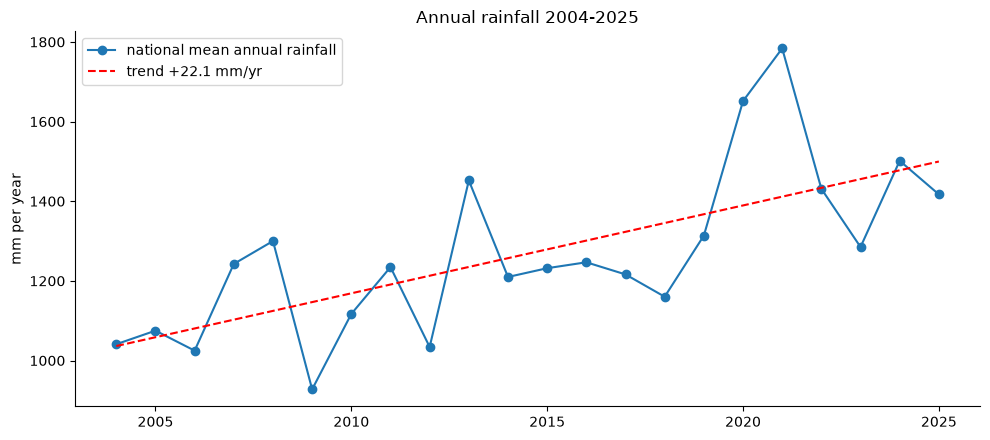

In [7]:
annual = win.groupby(["district_name", "year"]).rainfall_mm.sum().reset_index(name="annual_mm")


def trend(g):
    r = stats.linregress(g.year, g.annual_mm)
    return pd.Series({"trend_mm_per_yr": r.slope, "trend_p": r.pvalue})


trends = annual.groupby("district_name")[["year", "annual_mm"]].apply(trend)

# National view on the independent series only
nat_annual = annual[annual.district_name.isin(indep)].groupby("year").annual_mm.mean()
r_nat = stats.linregress(nat_annual.index, nat_annual.values)
print(f"National trend 2004-2025: {r_nat.slope:+.1f} mm/yr (p = {r_nat.pvalue:.3f})")
t_ind = trends.loc[trends.index.isin(indep)]
print(f"Independent series with significant (p<0.05) trends: {(t_ind.trend_p < 0.05).sum()} of {len(t_ind)}"
      f" | rising: {((t_ind.trend_p < 0.05) & (t_ind.trend_mm_per_yr > 0)).sum()}")

ax = nat_annual.plot(marker="o", label="national mean annual rainfall")
ax.plot(nat_annual.index, r_nat.intercept + r_nat.slope * nat_annual.index, "r--", label=f"trend {r_nat.slope:+.1f} mm/yr")
ax.set(title="Annual rainfall 2004-2025", ylabel="mm per year", xlabel="")
ax.legend()
savefig("02_rainfall_trend.png")

### Step 1.3: Baseline vs recent anomaly, and extreme-day frequency

**Concept: anomaly.** How different are recent years from "normal"?

$$\text{Anomaly (\%)} = \frac{\text{Recent avg} - \text{Baseline avg}}{\text{Baseline avg}} \times 100$$

**Decision: baseline 2004–2019 (16 years), recent 2020–2025 (6 full years).** This is the split suggested in the brief. The baseline is long enough to represent "normal", and the recent window covers the years leading up to the 2026 event. 2026 is excluded because it is incomplete.

**Decision: what counts as "meaningful"?** Rainfall naturally wobbles from year to year. We measure the typical wobble with the **coefficient of variation (CV)** of baseline years (standard deviation ÷ mean, as a %). An anomaly is called *meaningful* only if it is **larger than one typical year's wobble** (|anomaly| > CV). Otherwise it could easily be normal variation.

In [8]:
base = annual[annual.year.between(2004, 2019)].groupby("district_name").annual_mm
recent = annual[annual.year.between(2020, 2025)].groupby("district_name").annual_mm.mean()
anom = pd.DataFrame({
    "baseline_mm": base.mean(),
    "recent_mm": recent,
    "baseline_cv_pct": base.std() / base.mean() * 100,
})
anom["anomaly_pct"] = (anom.recent_mm - anom.baseline_mm) / anom.baseline_mm * 100
anom["meaningful"] = anom.anomaly_pct.abs() > anom.baseline_cv_pct

a_ind = anom.loc[anom.index.isin(indep)]
print(f"Median anomaly (independent series): {a_ind.anomaly_pct.median():+.1f}%")
print(f"Median baseline year-to-year CV:     {a_ind.baseline_cv_pct.median():.1f}%")
print(f"Series with a meaningful anomaly:     {a_ind.meaningful.sum()} of {len(a_ind)}"
      f" (wetter: {(a_ind.meaningful & (a_ind.anomaly_pct > 0)).sum()})")

Median anomaly (independent series): +26.9%
Median baseline year-to-year CV:     15.7%
Series with a meaningful anomaly:     33 of 45 (wetter: 33)


Extreme days per district-year: baseline 6.0 -> recent 8.9 (+49%), trend +0.13 days/yr (p=0.050)


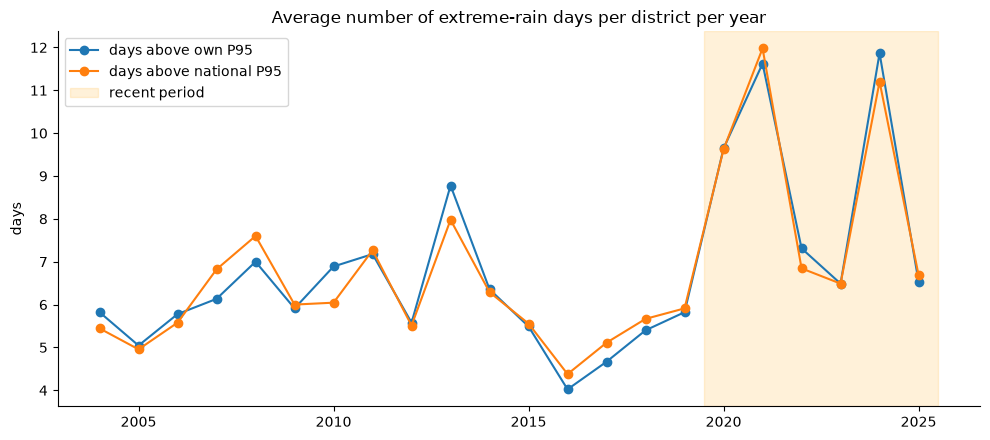

In [9]:
# Extreme-day frequency over time (independent series), local and national definitions.
ext_year = win[win.district_name.isin(indep)].groupby("year")[["extreme_local", "extreme_national"]].sum() / len(indep)
ext_year.columns = ["days above own P95", "days above national P95"]

r_ext = stats.linregress(ext_year.index, ext_year["days above own P95"])
b, rcnt = ext_year.loc[2004:2019].mean(), ext_year.loc[2020:2025].mean()
print(f"Extreme days per district-year: baseline {b.iloc[0]:.1f} -> recent {rcnt.iloc[0]:.1f}"
      f" ({(rcnt.iloc[0] / b.iloc[0] - 1) * 100:+.0f}%), trend {r_ext.slope:+.2f} days/yr (p={r_ext.pvalue:.3f})")

ax = ext_year.plot(marker="o")
ax.axvspan(2019.5, 2025.5, color="orange", alpha=0.15, label="recent period")
ax.set(title="Average number of extreme-rain days per district per year", ylabel="days", xlabel="")
ax.legend()
savefig("03_extreme_days.png")

### Step 1.4: 2026 in context (partial year, compared like-for-like)
2026 cannot be compared as a full year, but we can compare **January–August 2026** against January–August of every other year. That is a fair, like-for-like comparison.

In [10]:
ja = climate[(climate.date.dt.month <= 8) & climate.district_name.isin(indep) & (climate.date.dt.year >= 2004)]
ja_tot = ja.groupby([ja.date.dt.year, "district_name"]).rainfall_mm.sum().groupby(level=0).mean()
rank = ja_tot.rank(ascending=False)[2026]
print(f"Jan-Aug 2026 national mean rainfall: {ja_tot[2026]:,.0f} mm  "
      f"(2004-2025 Jan-Aug average {ja_tot.loc[2004:2025].mean():,.0f} mm); ranks #{int(rank)} of {len(ja_tot)} years")

corridor = ["SINDHUPALCHOK", "RASUWA", "NUWAKOT"]
aug = climate[climate.district_name.isin(corridor) & (climate.date >= "2026-08-15") & (climate.date <= "2026-08-30")]
print("\nBhote Koshi / Trishuli corridor, rainfall 15-30 Aug 2026 (mm/day):")
print(aug.pivot(index="date", columns="district_name", values="rainfall_mm").T.round(0).to_string())

Jan-Aug 2026 national mean rainfall: 1,315 mm  (2004-2025 Jan-Aug average 1,014 mm); ranks #3 of 23 years

Bhote Koshi / Trishuli corridor, rainfall 15-30 Aug 2026 (mm/day):
date           2026-08-15  2026-08-16  2026-08-17  2026-08-18  2026-08-19  2026-08-20  2026-08-21  2026-08-22  2026-08-23  2026-08-24  2026-08-25  2026-08-26  2026-08-27  2026-08-28  2026-08-29  2026-08-30
district_name                                                                                                                                                                                                
NUWAKOT             34.00       38.00       26.00       19.00       26.00       14.00       46.00       16.00       11.00       20.00       35.00       21.00        5.00       11.00       34.00       10.00
RASUWA              30.00       22.00       16.00       21.00       31.00       17.00       27.00       12.00        5.00       18.00       33.00       19.00        6.00        7.00       24.00       14.00
SI

**Concept check: why might rainfall *not* explain the 26 Aug event?** The brief says it was a **glacier and rock-and-ice collapse**. That is triggered by ice and slope instability at very high altitude, not necessarily by local rain. A satellite rain series for one point per district will not capture it. This is an important honesty point: **not every disaster is a rainfall disaster.** It is also why "terrain / glacial monitoring" appears as a separate investment category.

### Step 1.5: Record the five-column summary table (reused in Phase 6)

In [11]:
climate_summary = pd.DataFrame({
    "mean_daily_rain_mm": win.groupby("district_name").rainfall_mm.mean(),
    "p95_threshold_mm": p95,
    "extreme_days_per_yr": win.groupby("district_name").extreme_local.sum() / win.year.nunique(),
    "trend_mm_per_yr": trends.trend_mm_per_yr,
    "anomaly_pct": anom.anomaly_pct,
})
# Extra columns used later: national-threshold extreme days (comparable across districts) and the climate cluster.
climate_summary["nat_extreme_days_per_yr"] = win.groupby("district_name").extreme_national.sum() / win.year.nunique()
climate_summary = climate_summary.join(clusters.set_index("district_name")[["climate_grid_cluster", "cluster_size"]])
climate_summary.round(2).to_csv(f"{OUT}/phase1_climate_summary.csv")
climate_summary.sort_values("nat_extreme_days_per_yr", ascending=False).head(10)

,mean_daily_rain_mm,p95_threshold_mm,extreme_days_per_yr,trend_mm_per_yr,anomaly_pct,nat_extreme_days_per_yr,climate_grid_cluster,cluster_size
district_name,,,,,,,,
JHAPA,5.37,37.95,8.32,42.30,42.87,14.36,UNIQUE_JHAPA,1
PARBAT,4.87,42.08,6.91,47.69,35.64,14.05,CLUSTER_18,3
PALPA,4.87,42.08,6.91,47.69,35.64,14.05,CLUSTER_18,3
SYANGJA,4.87,42.08,6.91,47.69,35.64,14.05,CLUSTER_18,3
PARASI,4.44,44.80,6.59,23.46,23.29,13.50,UNIQUE_PARASI,1
GULMI,4.42,40.11,6.68,19.23,14.99,13.14,CLUSTER_1,3
PYUTHAN,4.42,40.11,6.68,19.23,14.99,13.14,CLUSTER_1,3
ARGHAKHANCHI,4.42,40.11,6.68,19.23,14.99,13.14,CLUSTER_1,3
KAPILVASTU,4.11,44.37,6.14,10.55,10.49,12.59,CLUSTER_12,2


### Phase 1 findings (named so Phase 7 can cite them)

**F1. Rainfall has increased materially since 2004.**
- National annual rainfall trend: **+22 mm per year** (p < 0.001). Over 22 years that is roughly +480 mm.
- **26 of 45** independent climate series have a statistically significant trend, and **all 26 are rising**.
- Recent years (2020–25) vs baseline (2004–19): median anomaly **+27%**, against a typical year-to-year wobble (CV) of about 16%. **33 of 45** series show a *meaningful* anomaly, all wetter.

**F2. Extreme rain days are more frequent.** The average district went from **6.0 to 8.9** extreme-rain days per year (**+49%**). The year-by-year trend is borderline significant (p = 0.05), so we describe it as "strong indication", not proof.

**F3. 2026 was a wet year, but the 26 Aug event was not a rain extreme.** January–August 2026 was the **3rd wettest** of 23 years. Yet rainfall in the Bhote Koshi corridor on 26 Aug was about 20 mm, *below* the extreme threshold (~30 mm). This is consistent with the brief: the trigger was a glacier/ice collapse. **Rainfall data alone would not have flagged it.**

**Caveats to state:**
- (a) Rasuwa and Sindhupalchok show *identical* rain because they share one NASA grid cell.
- (b) Satellite products are periodically re-processed, so part of a trend can be instrumental. We removed the known 2004 break, but cannot rule out smaller ones.

**How to say it:** *"Using only the reliable 2004–2025 satellite record, rainfall is rising about 22 mm a year, recent years are roughly a quarter wetter than the baseline, and extreme-rain days are up by about half. But the August 2026 disaster happened on an ordinary rain day. It was an ice collapse, which tells us rainfall monitoring alone is not enough."*

---
# Phase 2: Physical hazard (terrain and rivers)

**Goal:** measure how much each district's *geography*, regardless of weather, predisposes it to landslides and floods.

### Step 2.1: Terrain ruggedness
**Concept: standard deviation of elevation.** Standard deviation measures *spread*. A district whose land ranges from 500 m valleys to 5,000 m peaks has a large spread, meaning steep, broken, landslide-prone terrain. A flat plains (Terai) district has nearly zero spread.

We use `elevation_std_m` because the slope columns are broken. Let's prove that claim rather than just trusting it:

      slope_mean_deg  elevation_std_m
mean           89.50           634.82
std             0.96           443.55
min            86.14            54.24
max            90.00         1,731.73


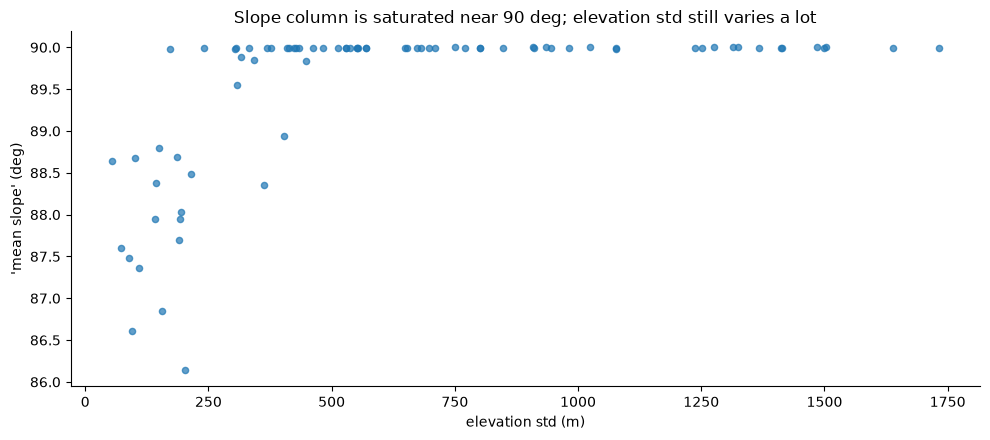

In [12]:
print(expo[["slope_mean_deg", "elevation_std_m"]].describe().loc[["mean", "std", "min", "max"]])
ax = expo.plot.scatter("elevation_std_m", "slope_mean_deg", alpha=0.7)
ax.set(title="Slope column is saturated near 90 deg; elevation std still varies a lot",
       xlabel="elevation std (m)", ylabel="'mean slope' (deg)")
savefig("04_slope_bug.png")

A real mean slope of 89.99° would mean near-vertical cliffs across whole districts, which is physically impossible. The column has almost no variation, so it cannot tell districts apart. Elevation spread ranges from tens of metres to thousands, so it **does** discriminate.

### Step 2.2: River magnitude **and** proximity, together
- **River magnitude:** `flow_acc_max` counts how many upstream cells drain through the district's biggest channel. More upstream area means a bigger river.
- **Proximity:** `dist_to_river_mean_km`: on average, how close the land sits to a river channel. Closer means more land within reach of floodwater.

**Concept: skew and log transform.** River sizes are extremely uneven: a few districts sit on rivers draining most of Nepal, and most don't. If we min-max raw values, one giant river scores 100 and everyone else is squashed near 0. Taking the **logarithm** compresses the giants so differences among ordinary districts become visible. (Log turns "10× bigger" into "+1 step".) We do the same for other skewed variables later.

**Concept: why combine with a geometric mean, not an average?** The brief says a large river far from settlement is a different risk from a small stream through a town. We want the score to be high only when **both** the river is big **and** the land is close to rivers.
- Average of 100 and 0 = 50 (misleadingly medium).
- **Geometric mean** $\sqrt{a \times b}$ of 100 and 0 = 0, so one missing ingredient pulls the score down.

In [13]:
phys = expo.set_index("district_name")[["district_id", "province", "elevation_mean_m", "elevation_max_m",
                                         "elevation_std_m", "flow_acc_max", "dist_to_river_mean_km",
                                         "has_major_river"]].copy()

phys["ruggedness_score"] = minmax(phys.elevation_std_m)
phys["river_size_score"] = minmax(np.log10(phys.flow_acc_max))
phys["river_proximity_score"] = minmax(-phys.dist_to_river_mean_km)   # minus sign: closer = higher
phys["river_score"] = minmax(np.sqrt(phys.river_size_score * phys.river_proximity_score))

print("Correlation between terrain and river variables (Spearman):")
print(phys[["ruggedness_score", "river_size_score", "river_proximity_score"]].corr("spearman").round(2))

Correlation between terrain and river variables (Spearman):
                       ruggedness_score  river_size_score  river_proximity_score
ruggedness_score                   1.00              0.06                   0.16
river_size_score                   0.06              1.00                   0.34
river_proximity_score              0.16              0.34                   1.00


**Concept: correlation.** A number from −1 to +1 saying whether two things rise together (+), move opposite (−), or are unrelated (≈0). We use **Spearman** correlation, which compares *rankings* rather than raw values. This makes it robust to extreme outliers such as Kathmandu.

### Which districts combine rugged terrain AND large nearby rivers?
**Physical basis for treating them jointly:** a landslide in steep terrain can dam a river, and when the dam bursts it becomes a flood far downstream. Glacial and ice collapses (like 26 Aug 2026) send debris down steep valleys *through* river corridors. Steep slopes plus big rivers produce cascading hazards, which are worse than either alone.

8 districts are in the top third for BOTH ruggedness and river score:
              province  elevation_std_m  elevation_max_m  ruggedness_score  river_score
district_name                                                                          
GORKHA         Gandaki         1,732.00         7,463.00            100.00        78.00
SANKHUWASABHA    Koshi         1,485.00         7,037.00             85.00        79.00
RAMECHHAP      Bagmati         1,238.00         6,393.00             71.00        78.00
DHADING        Bagmati         1,078.00         5,889.00             61.00        78.00
MUGU           Karnali         1,076.00         6,123.00             61.00        81.00
HUMLA          Karnali           946.00         6,388.00             53.00        80.00
RUKUM WEST     Karnali           935.00         5,604.00             53.00        78.00
KALIKOT        Karnali           749.00         4,403.00             41.00        82.00


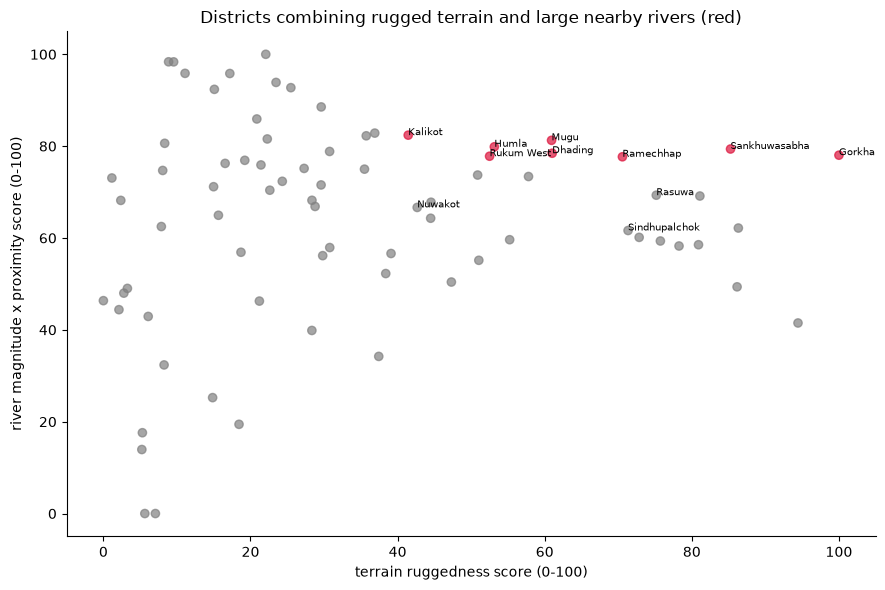

In [14]:
q = 2 / 3
phys["steep_and_river"] = (phys.ruggedness_score >= phys.ruggedness_score.quantile(q)) & \
                          (phys.river_score >= phys.river_score.quantile(q))
print(f"{phys.steep_and_river.sum()} districts are in the top third for BOTH ruggedness and river score:")
print(phys[phys.steep_and_river].sort_values("ruggedness_score", ascending=False)
      [["province", "elevation_std_m", "elevation_max_m", "ruggedness_score", "river_score"]].round(0))

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(phys.ruggedness_score, phys.river_score, c=np.where(phys.steep_and_river, "crimson", "grey"), alpha=0.7)
for n, r in phys[phys.steep_and_river | phys.index.isin(corridor)].iterrows():
    ax.annotate(n.title(), (r.ruggedness_score, r.river_score), fontsize=7)
ax.set(xlabel="terrain ruggedness score (0-100)", ylabel="river magnitude x proximity score (0-100)",
       title="Districts combining rugged terrain and large nearby rivers (red)")
savefig("05_terrain_river.png")

**F4. Terrain and rivers are independent signals.** Ruggedness and river size are almost uncorrelated (ρ ≈ 0.06), so each adds new information. **8 districts** are in the top third for both: Gorkha, Sankhuwasabha, Ramechhap, Dhading, Mugu, Humla, Rukum West and Kalikot. All but Kalikot have peaks above 5,000 m, meaning glacial and high-mountain terrain drains straight into major rivers.

**Decision (initial; tested in Phase 6): keep terrain and climate hazard separate for now.**
Floods and landslides have different physical drivers:
- **Flood hazard** = river score + heavy-rain score (water volume).
- **Landslide hazard** = ruggedness score + heavy-rain score (unstable slopes + trigger).

Merging everything into one hazard number now would hide which driver matters. Phase 6 will test whether separate indices are actually better.

**How to say it:** *"We measured terrain with the spread of elevation, because the supplied slope data is corrupted. We measured flood-prone hydrology as river size combined with closeness to rivers. The districts that score high on both, steep and on major rivers, are the corridors where cascading events like the August collapse happen."*

---
# Phase 3: Exposure (what is in harm's way)

**Variables used:** population, population density, hydropower capacity (MW), hospital count, school count.

**Decision: log-transform before min-max.** These are all heavily skewed (Kathmandu's density is many times the next district; most districts have 0 MW of hydropower). Without the log, almost every district would score near 0. We show the problem first:

In [15]:
EXPO_VARS = ["population", "population_density_per_km2", "hydropower_capacity_mw", "hospital_count", "school_count"]
ex = expo.set_index("district_name")[EXPO_VARS].copy()

raw_scores = ex.apply(minmax)
log_scores = np.log1p(ex).apply(minmax)    # log1p = log(1 + x), safe when x = 0
compare = pd.DataFrame({"median score, raw min-max": raw_scores.median(),
                        "median score, log then min-max": log_scores.median()})
compare

,"median score, raw min-max","median score, log then min-max"
population,11.96,64.28
population_density_per_km2,3.14,52.00
hydropower_capacity_mw,0.00,0.00
hospital_count,5.88,41.99
school_count,20.55,68.49


With raw min-max, the *typical* district scores close to zero on most variables, because one extreme district stretches the scale. After the log, scores spread across the range and districts can be told apart.

**Decision: weights.**

| Variable | Weight | Reason |
|---|---|---|
| Population | 30% | Saving lives is the first priority; people are the core of exposure |
| Population density | 20% | Dense settlement means more people per hectare hit by any single event |
| Hydropower capacity | 20% | Critical national infrastructure, directly damaged in the Aug 2026 event |
| Hospitals | 15% | Critical facilities (loss amplifies impact) |
| Schools | 15% | Critical facilities and common evacuation shelters |

People get 50% in total, infrastructure 50%. The weights are a stated judgment; Phase 6 checks whether a simple equal-weight version ranks districts differently.

In [16]:
W_EXPO = {"population": 0.30, "population_density_per_km2": 0.20, "hydropower_capacity_mw": 0.20,
          "hospital_count": 0.15, "school_count": 0.15}
exposure = pd.DataFrame(log_scores.add_suffix("_score"))
exposure["exposure_score"] = minmax(sum(log_scores[v] * w for v, w in W_EXPO.items()))
exposure["exposure_equal_wt"] = minmax(log_scores.mean(axis=1))
rho = stats.spearmanr(exposure.exposure_score, exposure.exposure_equal_wt)[0]
print(f"Rank agreement between our weights and equal weights: Spearman rho = {rho:.2f}")
exposure.join(ex).sort_values("exposure_score", ascending=False).head(10)[
    ["exposure_score"] + EXPO_VARS].round(1)

Rank agreement between our weights and equal weights: Spearman rho = 0.99


,exposure_score,population,population_density_per_km2,hydropower_capacity_mw,hospital_count,school_count
district_name,,,,,,
KATHMANDU,100.00,2041587,5169,0.60,205,1528
KASKI,91.20,600051,297,145.20,60,591
LALITPUR,83.30,551667,1433,6.40,54,487
RUPANDEHI,82.50,1121957,825,1.00,46,897
MAKWANPUR,82.40,466073,192,128.00,17,553
PARASI,80.50,386868,527,15.00,72,361
SYANGJA,79.70,253024,217,153.40,39,244
DOLAKHA,76.70,172767,79,586.90,13,413
DHANUSA,75.40,867747,735,0.00,43,539


**F5. Exposure concentrates in cities and hydropower hubs.** Kathmandu, Kaski, Lalitpur, Rupandehi and Makwanpur lead. Dolakha (587 MW, the largest hydropower district) ranks 8th despite a small population. Our weights barely matter: the equal-weight version ranks districts almost identically (ρ = 0.99).

**How to say it:** *"Exposure combines people and critical assets. We log-scaled them so a few giant districts don't flatten everyone else, then weighted people and infrastructure 50/50. An equal-weight version produces almost the same ranking, so the result is not sensitive to our weighting choice."*

---
# Phase 4: Vulnerability (how badly impacts would hurt, and how hard it is to respond)

Two independent indicators, as the brief suggests:
1. **Road density** (km of road per km² of land): low means slow rescue, hard evacuation, slow relief. *Low road density = high vulnerability*, so we invert the score.
2. **Population per hospital**: high means health services are overwhelmed in a mass-casualty event. *High = high vulnerability.*

**Decision: districts with zero hospitals.** Dividing by zero is undefined. Our rule: a zero-hospital district is assigned the **worst** (highest) population-per-hospital value in the dataset, because having no hospital is at least as bad as the worst district that has one. (In this dataset every district has at least one mapped hospital, so the rule is written in code but does not trigger. It is still documented in case the data changes.)

In [17]:
vu = expo.set_index("district_name")[["population", "hospital_count", "road_density_km_per_km2"]].copy()
print("districts with zero hospitals:", (vu.hospital_count == 0).sum())

vu["pop_per_hospital"] = vu.population / vu.hospital_count.replace(0, np.nan)
vu["pop_per_hospital"] = vu.pop_per_hospital.fillna(vu.pop_per_hospital.max())   # zero-hospital rule

vu["access_vuln_score"] = 100 - minmax(np.log(vu.road_density_km_per_km2))
vu["health_vuln_score"] = minmax(np.log(vu.pop_per_hospital))
vu["vulnerability_score"] = minmax((vu.access_vuln_score + vu.health_vuln_score) / 2)

print("Do the two indicators measure different things?  Spearman =",
      round(stats.spearmanr(vu.access_vuln_score, vu.health_vuln_score)[0], 2))
vu.sort_values("vulnerability_score", ascending=False).head(10).round(2)

districts with zero hospitals: 0
Do the two indicators measure different things?  Spearman = -0.11


,population,hospital_count,road_density_km_per_km2,pop_per_hospital,access_vuln_score,health_vuln_score,vulnerability_score
district_name,,,,,,,
TAPLEJUNG,120590,1,0.17,"120,590.00",61.24,92.11,100.00
DARCHULA,133310,1,0.20,"133,310.00",58.40,94.23,99.38
BAJURA,138523,4,0.12,"34,630.75",67.30,65.81,82.88
SANKHUWASABHA,158041,2,0.37,"79,020.50",48.85,83.20,81.99
KHOTANG,175298,1,1.06,"175,298.00",31.89,100.00,81.85
MYAGDI,107033,2,0.24,"53,516.50",55.99,74.98,81.08
RUKUM EAST,56786,2,0.13,"28,393.00",65.48,61.62,77.80
BARDIYA,459900,3,1.46,"153,300.00",26.73,97.17,75.10
MUSTANG,14452,1,0.08,"14,452.00",73.42,47.38,72.48


**F6. Vulnerability is highest in remote mountain districts.** Taplejung, Darchula, Bajura, Sankhuwasabha, Khotang and Myagdi lead: sparse roads and one or two mapped hospitals for over 100,000 people. The two indicators are nearly unrelated (ρ ≈ −0.11), so they genuinely capture two different weaknesses.

### What this vulnerability measure does NOT capture (stated explicitly, as required)
| Missing factor | Why it matters |
|---|---|
| **Poverty / income** | Poor households have weaker houses, no savings, no insurance |
| **Age structure** (children, elderly) | Less able to evacuate; higher mortality |
| **Disability, gender, caste/ethnicity** | Known drivers of unequal disaster impact in Nepal |
| **Housing construction type** | Mud/stone houses collapse in landslides; RCC buildings may not |
| **Literacy and early-warning coverage** | Determines whether warnings are received and acted on |
| **Distance to hospital, not just count** | One hospital in a huge mountain district may be days away |
| **Trails and footbridges** | Excluded from road data on purpose, yet in the hills they *are* the access network |
| **OSM mapping bias** | Rural hospitals and roads are under-mapped, so remote districts may look *more* vulnerable or less, depending on what was mapped |

`sex_ratio` and `annual_growth_rate` were considered and rejected. A low male-to-female ratio in Nepal mostly reflects labour migration abroad, which has mixed effects on vulnerability, and we cannot justify a direction.

**How to say it:** *"Vulnerability is measured by two proxies we actually have: road access and hospital capacity. Poverty, age, and housing quality are not in the data. That is a real limitation, and it's why part of the investment goes to data."*

---
# Phase 5: Building the composite risk score

### Step 5.0: Hazard sub-scores
- **Rain hazard** = how often a district gets rain above the *national* extreme threshold. The national ruler is used so districts can be compared.
- **Flood hazard** = average of rain hazard and river score.
- **Landslide hazard** = average of rain hazard and ruggedness score.
- **Combined hazard** = average of rain, river, and ruggedness.

In [18]:
df = phys.join(climate_summary).join(exposure[["exposure_score", "exposure_equal_wt"]]) \
         .join(vu[["pop_per_hospital", "road_density_km_per_km2", "access_vuln_score",
                   "health_vuln_score", "vulnerability_score"]]) \
         .join(expo.set_index("district_name")[EXPO_VARS])

df["rain_score"] = minmax(df.nat_extreme_days_per_yr)
df["flood_hazard"] = minmax((df.rain_score + df.river_score) / 2)
df["landslide_hazard"] = minmax((df.rain_score + df.ruggedness_score) / 2)
df["combined_hazard"] = minmax((df.rain_score + df.river_score + df.ruggedness_score) / 3)
df[["rain_score", "river_score", "ruggedness_score", "flood_hazard", "landslide_hazard"]].describe().round(1)

,rain_score,river_score,ruggedness_score,flood_hazard,landslide_hazard
count,77.00,77.00,77.00,77.00,77.00
mean,47.40,64.50,34.60,57.50,35.00
std,26.60,21.90,26.40,23.10,19.60
min,0.00,0.00,0.00,0.00,0.00
25%,28.00,55.10,15.00,42.30,21.00
50%,44.10,68.20,28.40,55.50,34.60
75%,68.40,78.50,51.00,73.70,43.90
max,100.00,100.00,100.00,100.00,100.00


### Step 5.1 / 5.2: Multiplicative vs additive

**Multiplicative** (Risk = H × E × V): matches the definition of risk. If any ingredient is zero (no hazard, or nobody there), risk is zero. We use the **geometric mean** $\sqrt[3]{H \times E \times V}$ so the result stays on a 0–100 scale.

**Weighted additive** (Risk = 0.4H + 0.3E + 0.3V): simpler, but a district with huge exposure and *no* hazard still scores medium. That contradicts what risk means.

**Decision: multiplicative (geometric mean).** It reflects the risk concept and is standard in global indices such as INFORM.

**Technical detail:** min-max gives the lowest district exactly 0, which would zero its whole risk score. We floor each component at 1 before multiplying, so the lowest district is "very low" but still comparable.

In [19]:
def geo_risk(h, e, v):
    return minmax(np.cbrt(h.clip(lower=1) * e.clip(lower=1) * v.clip(lower=1)))


df["risk_combined"] = geo_risk(df.combined_hazard, df.exposure_score, df.vulnerability_score)
df["risk_flood"] = geo_risk(df.flood_hazard, df.exposure_score, df.vulnerability_score)
df["risk_landslide"] = geo_risk(df.landslide_hazard, df.exposure_score, df.vulnerability_score)
df["risk_additive"] = minmax(0.4 * df.combined_hazard + 0.3 * df.exposure_score + 0.3 * df.vulnerability_score)

print("Rank agreement multiplicative vs additive: rho =",
      round(stats.spearmanr(df.risk_combined, df.risk_additive)[0], 2))
cols = ["province", "combined_hazard", "exposure_score", "vulnerability_score", "risk_combined", "risk_flood", "risk_landslide"]
df.sort_values("risk_combined", ascending=False)[cols].head(15).round(1)

Rank agreement multiplicative vs additive: rho = 0.9


,province,combined_hazard,exposure_score,vulnerability_score,risk_combined,risk_flood,risk_landslide
district_name,,,,,,,
MYAGDI,Gandaki,99.80,56.80,81.10,100.00,91.40,100.00
DARCHULA,Sudurpashchim,72.40,55.50,99.40,94.70,77.40,79.00
TAPLEJUNG,Koshi,77.20,48.80,100.00,92.60,75.40,82.70
SANKHUWASABHA,Koshi,81.40,50.60,82.00,88.60,74.60,73.00
PYUTHAN,Lumbini,86.30,63.60,58.90,87.10,94.90,78.70
BARDIYA,Lumbini,76.40,56.20,75.10,87.00,100.00,57.80
GORKHA,Gandaki,87.70,69.70,50.40,85.40,67.90,73.30
KASKI,Gandaki,100.00,91.20,30.40,81.90,71.80,83.90
SUNSARI,Koshi,67.40,75.20,53.40,81.10,93.50,43.60


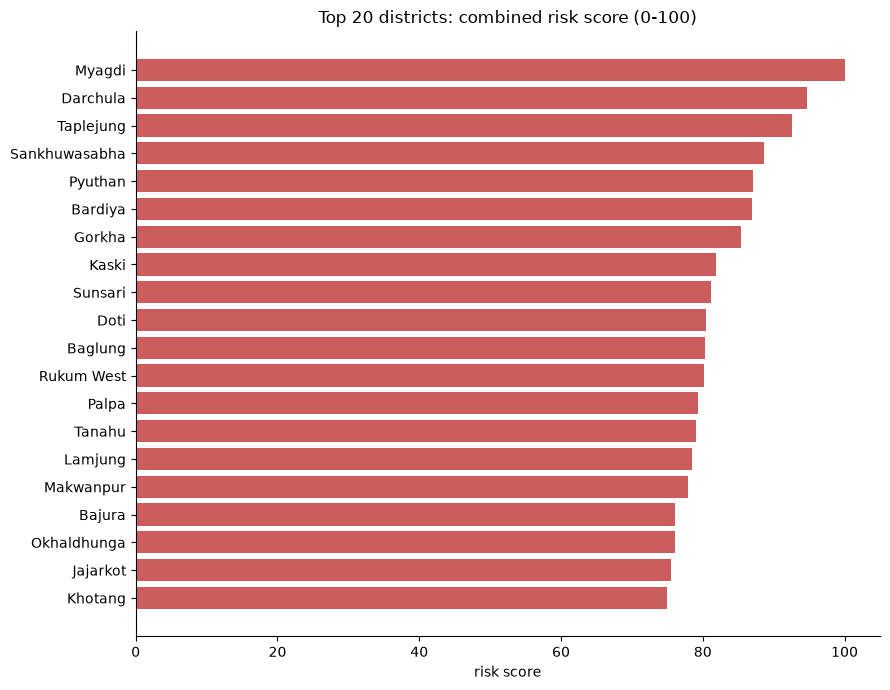

In [20]:
top = df.sort_values("risk_combined").tail(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index.str.title(), top.risk_combined, color="indianred")
ax.set(title="Top 20 districts: combined risk score (0-100)", xlabel="risk score")
savefig("06_top20_risk.png")

**Checkpoint:** one composite risk score per district (plus flood and landslide versions), built from a stated formula.

**How to say it:** *"Each district's risk is the geometric mean of hazard, exposure and vulnerability. Risk is only high where all three are high, which matches the definition of disaster risk used by the UN."*

---
# Phase 6: Validation against historical records (the most important phase)

Until now, our index is a **hypothesis**: "these districts are riskiest". Now we test it against 15 years of real recorded disasters. A model that doesn't match reality must be reported honestly, **not tweaked until it looks good**. Tweaking until the numbers fit is called *overfitting* or "p-hacking", and the brief explicitly forbids it.

### Step 6.1: Aggregate events to districts
**Decision: hazard categories.** `Flood` events count as floods, `Landslide` as landslides. `Heavy Rainfall` (3,321 events) and `Avalanche` (46) are counted in the total but not in either specific category, because "heavy rainfall" events could be either hazard and we won't guess.

In [21]:
ev = events.copy()
agg = ev.groupby("district_name").agg(
    events_total=("incident_id", "size"),
    deaths=("deaths", "sum"),
    flood_events=("hazard", lambda h: (h == "Flood").sum()),
    landslide_events=("hazard", lambda h: (h == "Landslide").sum()),
)
agg["deaths_flood"] = ev[ev.hazard == "Flood"].groupby("district_name").deaths.sum()
agg["deaths_landslide"] = ev[ev.hazard == "Landslide"].groupby("district_name").deaths.sum()
agg = agg.fillna(0)
df = df.join(agg)
print(agg.describe().T[["mean", "50%", "max"]].round(0))
print("\nCorrelation between flood counts and landslide counts across districts:",
      round(stats.spearmanr(df.flood_events, df.landslide_events)[0], 2))

                   mean    50%    max
events_total     163.00 161.00 365.00
deaths            42.00  38.00 149.00
flood_events      39.00  29.00 167.00
landslide_events  79.00  71.00 255.00
deaths_flood      14.00  10.00  57.00
deaths_landslide  26.00  16.00 138.00

Correlation between flood counts and landslide counts across districts: -0.14


### Step 6.2: Correlation between our scores and real outcomes
We correlate each score with each outcome. **How to read the table:** each cell is Spearman ρ (rho).
- ~0.1: no real relationship
- ~0.3: weak
- ~0.5: moderate
- ≥0.7: strong

Stars mark significance: \* p<0.05, \*\* p<0.01.

In [22]:
SCORES = ["risk_combined", "risk_flood", "risk_landslide", "combined_hazard", "flood_hazard", "landslide_hazard",
          "rain_score", "river_score", "ruggedness_score", "exposure_score", "vulnerability_score"]
OUTCOMES = ["events_total", "flood_events", "landslide_events", "deaths"]


def corr_table(data, scores, outcomes):
    rho, out = pd.DataFrame(index=scores, columns=outcomes, dtype=float), pd.DataFrame(index=scores, columns=outcomes)
    for s in scores:
        for o in outcomes:
            r, p = stats.spearmanr(data[s], data[o])
            rho.loc[s, o] = r
            out.loc[s, o] = f"{r:+.2f}" + ("**" if p < 0.01 else "*" if p < 0.05 else "")
    return rho, out


rho, corr_display = corr_table(df, SCORES, OUTCOMES)
corr_display

,events_total,flood_events,landslide_events,deaths
risk_combined,+0.39**,+0.12,+0.47**,+0.42**
risk_flood,+0.21,+0.23*,+0.10,+0.31**
risk_landslide,+0.41**,+0.02,+0.53**,+0.51**
combined_hazard,+0.28*,-0.25*,+0.45**,+0.38**
flood_hazard,+0.04,-0.09,+0.01,+0.19
landslide_hazard,+0.28*,-0.25*,+0.46**,+0.39**
rain_score,-0.01,+0.00,-0.11,+0.16
river_score,+0.01,-0.10,+0.10,+0.05
ruggedness_score,+0.35**,-0.27*,+0.67**,+0.24*
exposure_score,+0.11,+0.38**,-0.10,+0.26*


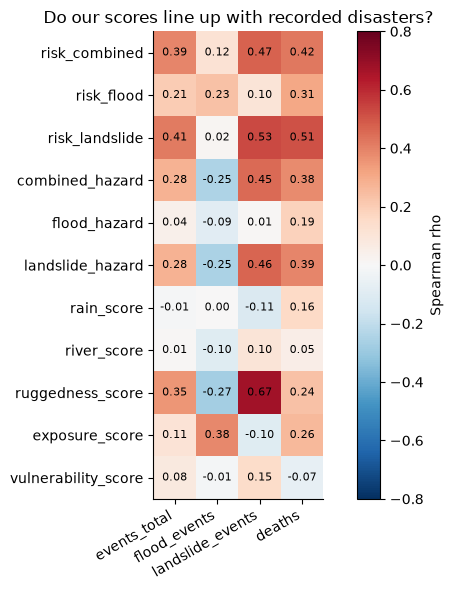

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(rho.values.astype(float), cmap="RdBu_r", vmin=-0.8, vmax=0.8)
ax.set_xticks(range(len(OUTCOMES)), OUTCOMES, rotation=30, ha="right")
ax.set_yticks(range(len(SCORES)), SCORES)
for i in range(len(SCORES)):
    for j in range(len(OUTCOMES)):
        ax.text(j, i, f"{rho.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="Spearman rho")
ax.set_title("Do our scores line up with recorded disasters?")
savefig("07_validation_heatmap.png")

### Step 6.3: Regression: which ingredients actually matter?
**Concept: multiple regression.** Correlation looks at one variable at a time. Regression looks at all of them **together**, and estimates each one's effect *while holding the others constant*.

- Outcome: `log(1 + event count)`. Logged, because a few districts have hundreds of events.
- Predictors: the five building blocks, **standardized** (converted to z-scores: 0 = average, 1 = one standard deviation above). Coefficients are then directly comparable: a bigger coefficient means a stronger effect.
- **R²** = share of the district-to-district differences the model explains (0 = nothing, 1 = everything).
- A predictor's **p-value < 0.05** means its effect is unlikely to be chance.

We run it three times: total events, flood events, landslide events (brief Step 6.4).

In [24]:
PRED = ["rain_score", "river_score", "ruggedness_score", "exposure_score", "vulnerability_score"]
X = sm.add_constant((df[PRED] - df[PRED].mean()) / df[PRED].std())

reg_rows, models = [], {}
for outcome in ["events_total", "flood_events", "landslide_events", "deaths"]:
    m = sm.OLS(np.log1p(df[outcome]), X).fit()
    models[outcome] = m
    row = {"outcome": outcome, "R2": m.rsquared, "adj_R2": m.rsquared_adj}
    for p in PRED:
        row[p] = f"{m.params[p]:+.2f}" + ("**" if m.pvalues[p] < 0.01 else "*" if m.pvalues[p] < 0.05 else "")
    reg_rows.append(row)
reg_table = pd.DataFrame(reg_rows).set_index("outcome")
reg_table

,R2,adj_R2,rain_score,river_score,ruggedness_score,exposure_score,vulnerability_score
outcome,,,,,,,
events_total,0.32,0.27,+0.09,+0.06,+0.19**,+0.22**,+0.11
flood_events,0.32,0.27,-0.07,-0.03,-0.17*,+0.38**,+0.28**
landslide_events,0.50,0.46,+0.27,+0.36**,+1.09**,-0.08,-0.28
deaths,0.36,0.31,+0.17*,+0.11,+0.28**,+0.36**,+0.13


### Step 6.4: Combined vs separate indices: the required methodological decision
Here is the fair test. If floods and landslides really have different drivers:
- The **flood index** should match **flood events** better than the **landslide index** does, and vice versa.
- Each hazard-specific index should beat the combined index on its own hazard.

In [25]:
def rho_of(s, o):
    return stats.spearmanr(df[s], df[o])[0]


decision = pd.DataFrame({
    "flood_events": [rho_of("risk_combined", "flood_events"), rho_of("risk_flood", "flood_events"),
                     rho_of("risk_landslide", "flood_events")],
    "landslide_events": [rho_of("risk_combined", "landslide_events"), rho_of("risk_flood", "landslide_events"),
                         rho_of("risk_landslide", "landslide_events")],
}, index=["combined index", "flood index", "landslide index"]).round(2)
decision

,flood_events,landslide_events
combined index,0.12,0.47
flood index,0.23,0.10
landslide index,0.02,0.53


### Step 6.5: Why might correlation be weak? Testing explanations rather than guessing
The brief asks us to *identify the most likely explanation* for weak results. We test three candidates with evidence.

**(a) Reporting has changed over time.** If recording practice improved, the event file reflects *who reported* as much as *what happened*.

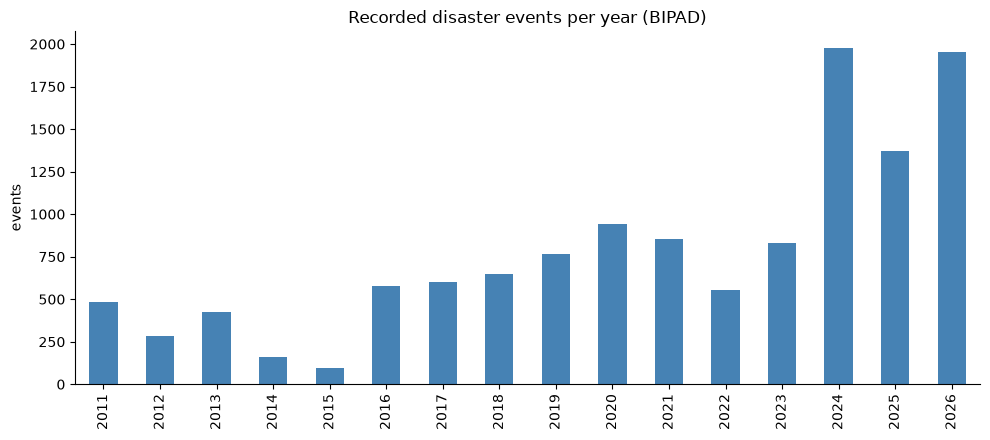

incident_date      2011   2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023     2024     2025     2026
events           481.00 284.00 426.00 163.00  95.00 576.00 603.00 647.00 764.00 943.00 852.00 554.00 832.00 1,976.00 1,370.00 1,952.00
deaths           247.00  89.00 231.00 261.00 139.00 258.00 250.00 125.00 176.00 359.00 264.00 129.00  81.00   456.00   110.00    76.00
deaths_per_event   0.51   0.31   0.54   1.60   1.46   0.45   0.41   0.19   0.23   0.38   0.31   0.23   0.10     0.23     0.08     0.04


In [26]:
by_year = events.groupby(events.incident_date.dt.year).agg(events=("incident_id", "size"), deaths=("deaths", "sum"))
by_year["deaths_per_event"] = by_year.deaths / by_year.events
ax = by_year.events.plot.bar(color="steelblue")
ax.set(title="Recorded disaster events per year (BIPAD)", xlabel="", ylabel="events")
savefig("08_events_by_year.png")
print(by_year.T.round(2).to_string())

**(b) Reporting depends on access.** If events are more often recorded where roads (and police posts) exist, recorded events partly measure *reporting capacity*. Deaths are harder to miss than minor incidents, so deaths should be less affected. We compare: do event counts correlate with road density more than deaths do?

In [27]:
for o in ["events_total", "flood_events", "landslide_events", "deaths"]:
    r, p = stats.spearmanr(df.road_density_km_per_km2, df[o])
    print(f"road density vs {o:17s} rho = {r:+.2f}  (p = {p:.3f})")

road density vs events_total      rho = -0.04  (p = 0.714)
road density vs flood_events      rho = +0.32  (p = 0.004)
road density vs landslide_events  rho = -0.31  (p = 0.007)
road density vs deaths            rho = -0.04  (p = 0.742)


**(c) Known events missing from the record.** The brief's own trigger event, the **26 Aug 2026 glacier collapse in the Bhote Koshi / Trishuli corridor**, should appear in a file running to 5 Sep 2026. Let's check:

In [28]:
late = events[(events.incident_date >= "2026-08-24") & (events.incident_date <= "2026-09-05")]
print("Events recorded 24 Aug - 5 Sep 2026 in the corridor districts:")
print(late[late.district_name.isin(corridor)][["incident_date", "district_name", "hazard", "deaths"]]
      if late.district_name.isin(corridor).any() else "  none")
print(f"\nAll events nationally in that window: {len(late)}, deaths: {late.deaths.sum()}")
print("Glacial lake outburst events in entire file:", (events.hazard == "Glacial lake outburst").sum())

# Where does our index place the event corridor?
for c in ["risk_combined", "risk_landslide", "risk_flood"]:
    df[c + "_rank"] = df[c].rank(ascending=False).astype(int)
df.loc[corridor + ["DOLAKHA"], ["elevation_max_m", "hydropower_capacity_mw", "risk_combined_rank",
                                "risk_landslide_rank", "risk_flood_rank", "deaths"]]

Events recorded 24 Aug - 5 Sep 2026 in the corridor districts:
           incident_date  district_name     hazard  deaths
3022 2026-08-30 18:15:00  SINDHUPALCHOK      Flood       0
9028 2026-08-24 18:15:00        NUWAKOT  Landslide       0
9037 2026-08-27 18:15:00  SINDHUPALCHOK  Landslide       0
9058 2026-08-29 18:15:00  SINDHUPALCHOK  Landslide       0
9090 2026-09-01 18:15:00        NUWAKOT  Landslide       0
9108 2026-09-01 18:15:00  SINDHUPALCHOK  Landslide       0

All events nationally in that window: 179, deaths: 5
Glacial lake outburst events in entire file: 0


,elevation_max_m,hydropower_capacity_mw,risk_combined_rank,risk_landslide_rank,risk_flood_rank,deaths
district_name,,,,,,
SINDHUPALCHOK,"6,466.00",149.62,21,19,57,149
RASUWA,"6,722.00",269.60,47,38,64,39
NUWAKOT,"5,001.00",48.09,40,39,49,37
DOLAKHA,"6,290.00",586.92,36,30,67,43


**(d) Structural limits.** Our climate signal has only 45 independent values for 77 districts, and comes from one point per district. A district's terrain can't tell us *where in the district* people live relative to slopes. Some disasters (glacial collapse, earthquake-triggered landslides) are not driven by our variables at all.

### Validation conclusion

**F7. The combined index has moderate, significant agreement with reality.** Combined risk vs total events ρ = **0.39**, vs deaths ρ = **0.42** (both p < 0.01). That is useful, but far from perfect.

**F8. The landslide index validates well.** Landslide risk vs landslide events ρ = **0.53**, vs deaths ρ = **0.51**. In the regression, **terrain ruggedness is by far the strongest driver** of landslide counts (coefficient +1.09, p < 0.01, R² = 0.50). Our model explains about half of the district differences, which is good for purely structural data.

**F9. The flood index fails validation, and we can explain why.**
- Flood risk vs flood events: ρ = only **0.23**. The flood *hazard* score alone is unrelated to flood events (ρ ≈ −0.09).
- The districts with the most recorded floods (Jhapa, Morang, Sunsari, Rautahat, Kailali) are **flat Terai lowlands**. Flood counts correlate *negatively* with ruggedness and *positively* with exposure (ρ = 0.38) and road density (ρ = 0.32).
- **Most likely explanation: an incorrect/missing variable, not wrong weights.** Our flood hazard measures mountain hydrology (big rivers, rainfall). Lowland floods happen where large rivers *leave* the mountains and spread across flat, densely populated plains, and no variable captures that. Floodplain flatness and water depth data are missing.
- Part of the pattern is also **reporting**: flood events are recorded more where roads and people are.
- As the brief instructs, we **report this rather than re-tuning the index**.

**F10. The event record has a serious reporting problem.**
- Recorded events rose from about 500–800 a year to **~2,000 a year** after 2023, while deaths per event fell from ~0.5 to **0.04**. That pattern means many more minor incidents are being logged: a change in *reporting*, not a 4× rise in disasters.
- **The 26 Aug 2026 glacier collapse, the event that prompted this assessment, is missing.** The corridor districts show only six minor events with zero deaths in the following ten days, despite reported significant loss of life.
- The file contains **no glacial lake outburst records at all**.

**F11. Our index cannot see glacial-collapse risk.** The event-corridor districts rank only **#21 (Sindhupalchok)** and **#47 (Rasuwa)** for combined risk. Rasuwa holds 270 MW of hydropower but few people. Glacial and ice hazard is not in our data; the closest proxy is "peaks above 5,000 m + high ruggedness".

### Decision: separate hazard-specific indices (required methodological decision)
Evidence:
1. Flood and landslide events occur in **different places** (ρ = −0.14 between them). One number cannot rank both well.
2. The **landslide index beats the combined index** on landslides (0.53 vs 0.47).
3. The **flood index beats the combined index** on floods (0.23 vs 0.12), although both are weak.
4. The combined index's apparent success is **almost entirely its landslide component**: it scores 0.47 on landslides but only 0.12 on floods.

So a single combined index would hide the fact that we predict landslides reasonably well and floods poorly. **We use separate flood and landslide indices**, and treat the flood index as low-confidence.

**How to say it:** *"We tested our index against 12,500 real disasters. For landslides it works: steep terrain explains about half the difference between districts. For floods it doesn't, because Nepal's floods happen on the flat southern plains and our data describes mountain rivers. And the record itself is incomplete: the August disaster isn't even in it. So we use two separate indices and invest in better data."*

---
# Phase 7: Investment recommendation (USD 100 million)

**Rule from the brief:** every dollar must trace to a *named finding* (F1–F11 above). Our approach:
1. **Targeting rule:** each budget line picks its districts with an explicit, reproducible rule, not by hand.
2. **Sizing logic:** money follows *confidence*. Where validation is strong (landslides, F8), we invest in targeted physical interventions. Where it is weak (floods F9, glacial F11, reporting F10), we invest in monitoring and data that fix the blind spot.

| Line | Intervention | Targeting rule | Traces to |
|---|---|---|---|
| 1a | Landslide early warning (rain-threshold alerts) | Top 8 districts by **landslide risk index** | F1, F2 (more extreme rain), F8 (validated index) |
| 1b | Flood early warning (river gauges + alerts) | Top 5 districts by **recorded flood events**, because the flood index failed validation | F9 |
| 2 | Terrain & glacial monitoring | Peaks > 5,000 m **and** top-third ruggedness **and** top-third river score, **plus** the 26 Aug event corridor | F3, F4, F11 |
| 3 | Infrastructure reinforcement (hydropower, hospitals, schools) | Above-median hazard **and** top-10 exposure, **plus** any district with ≥ 150 MW hydropower | F5, F3 (hydropower damaged 26 Aug) |
| 4 | Community preparedness | Above-median hazard **and** top-10 vulnerability | F6 |
| 5 | Data infrastructure | National (BIPAD reporting, rain gauges, floodplain mapping, poverty/age data), piloted in the 10 districts with the largest gap between hazard rank and recorded-event rank | F9, F10, F11, Phase 1 grid-cluster caveat |

In [29]:
hz_med = df.combined_hazard.median()
targets = {}
targets["1a Landslide early warning"] = df.sort_values("risk_landslide", ascending=False).head(8).index
targets["1b Flood early warning"] = df.sort_values("flood_events", ascending=False).head(5).index
glacial = df[(df.elevation_max_m > 5000) & df.steep_and_river].index
targets["2 Terrain & glacial monitoring"] = glacial.union(pd.Index(["SINDHUPALCHOK", "RASUWA"]))
infra = df[df.combined_hazard >= hz_med].sort_values("exposure_score", ascending=False).head(10).index
targets["3 Infrastructure reinforcement"] = infra.union(df[df.hydropower_capacity_mw >= 150].index)
targets["4 Community preparedness"] = df[df.combined_hazard >= hz_med].sort_values(
    "vulnerability_score", ascending=False).head(10).index

# Reporting gap: hazard ranks high but recorded events rank low -> likely under-reporting
df["reporting_gap"] = df.combined_hazard.rank(pct=True) - df.events_total.rank(pct=True)
targets["5 Data infrastructure"] = df.sort_values("reporting_gap", ascending=False).head(10).index

for cat, idx in targets.items():
    print(f"{cat} ({len(idx)}): {', '.join(i.title() for i in idx)}")

1a Landslide early warning (8): Myagdi, Kaski, Taplejung, Darchula, Pyuthan, Gorkha, Lamjung, Sankhuwasabha
1b Flood early warning (5): Jhapa, Morang, Sunsari, Kathmandu, Kailali
2 Terrain & glacial monitoring (9): Dhading, Gorkha, Humla, Mugu, Ramechhap, Rasuwa, Rukum West, Sankhuwasabha, Sindhupalchok
3 Infrastructure reinforcement (15): Chitwan, Dang, Dhading, Dolakha, Kailali, Kaski, Lamjung, Myagdi, Parasi, Ramechhap, Rasuwa, Solukhumbu, Sunsari, Syangja, Tanahu
4 Community preparedness (10): Taplejung, Darchula, Bajura, Sankhuwasabha, Myagdi, Rukum East, Bardiya, Mugu, Jajarkot, Doti
5 Data infrastructure (10): Surkhet, Parasi, Parbat, Nawalpur, Bardiya, Mugu, Salyan, Rukum East, Ramechhap, Gorkha


### Sizing each line (USD millions)

| Line | USD M | Why this size |
|---|---|---|
| 1a Landslide early warning | **18** | Our best-validated finding (F8, ρ = 0.53). Landslides are the most frequent recorded hazard (6,114 events) and rain extremes are rising (F2) |
| 1b Flood early warning | **10** | Floods are frequent in the Terai (F9), but our index can't rank them, so funding is limited to proven hotspots |
| 2 Terrain & glacial monitoring | **22** | The 26 Aug disaster was a glacial collapse (F3) that our index and the event record both missed (F10, F11). Ruggedness is the strongest single predictor (F8) |
| 3 Infrastructure reinforcement | **20** | Protects concentrated exposure (F5), including the hydropower assets damaged on 26 Aug |
| 4 Community preparedness | **15** | Remote districts with weak road and hospital access (F6) where outside help arrives slowest |
| 5 Data infrastructure | **15** | Flood index failure (F9), 4× reporting surge and missing 26 Aug event (F10), only 45 independent rain series for 77 districts (Phase 1), and missing poverty/age data (Phase 4) |
| **Total** | **100** | |

In [30]:
ALLOC = {
    "1a Landslide early warning": 18,
    "1b Flood early warning": 10,
    "2 Terrain & glacial monitoring": 22,
    "3 Infrastructure reinforcement": 20,
    "4 Community preparedness": 15,
    "5 Data infrastructure": 15,
}
FINDINGS = {
    "1a Landslide early warning": "F1, F2, F8",
    "1b Flood early warning": "F9",
    "2 Terrain & glacial monitoring": "F3, F4, F8, F11",
    "3 Infrastructure reinforcement": "F3, F5",
    "4 Community preparedness": "F6",
    "5 Data infrastructure": "F9, F10, F11",
}
assert sum(ALLOC.values()) == 100
alloc = pd.DataFrame({"usd_million": ALLOC, "findings": FINDINGS,
                      "n_districts": {c: len(t) for c, t in targets.items()},
                      "target_districts": {c: ", ".join(i.title() for i in t) for c, t in targets.items()}})
with pd.option_context("display.max_colwidth", 120):
    display(alloc)

,usd_million,findings,n_districts,target_districts
1a Landslide early warning,18,"F1, F2, F8",8,"Myagdi, Kaski, Taplejung, Darchula, Pyuthan, Gorkha, Lamjung, Sankhuwasabha"
1b Flood early warning,10,F9,5,"Jhapa, Morang, Sunsari, Kathmandu, Kailali"
2 Terrain & glacial monitoring,22,"F3, F4, F8, F11",9,"Dhading, Gorkha, Humla, Mugu, Ramechhap, Rasuwa, Rukum West, Sankhuwasabha, Sindhupalchok"
3 Infrastructure reinforcement,20,"F3, F5",15,"Chitwan, Dang, Dhading, Dolakha, Kailali, Kaski, Lamjung, Myagdi, Parasi, Ramechhap, Rasuwa, Solukhumbu, Sunsari, Sy..."
4 Community preparedness,15,F6,10,"Taplejung, Darchula, Bajura, Sankhuwasabha, Myagdi, Rukum East, Bardiya, Mugu, Jajarkot, Doti"
5 Data infrastructure,15,"F9, F10, F11",10,"Surkhet, Parasi, Parbat, Nawalpur, Bardiya, Mugu, Salyan, Rukum East, Ramechhap, Gorkha"


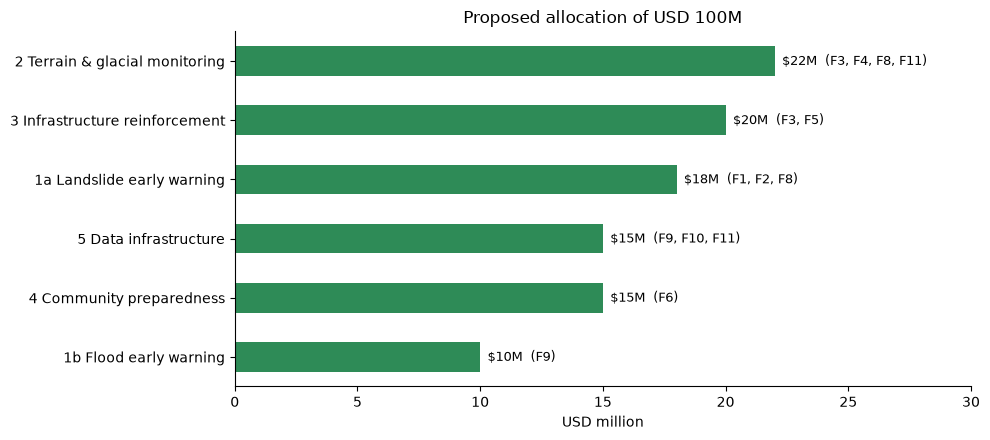

In [31]:
s = alloc.usd_million.sort_values()
ax = s.plot.barh(color="seagreen")
ax.set(title="Proposed allocation of USD 100M", xlabel="USD million", ylabel="")
for i, (cat, v) in enumerate(s.items()):
    ax.text(v + 0.3, i, f"${v}M  ({FINDINGS[cat]})", va="center", fontsize=9)
ax.set_xlim(0, 30)
savefig("09_allocation.png")

**How to say it:** *"Money follows evidence. Where our analysis is strong, on landslides, we fund targeted early warning. Where it revealed blind spots, like glacial collapse, lowland floods, and an incomplete disaster record, we fund monitoring and data, so the next assessment can see what this one couldn't."*

---
# Phase 8: Save outputs for the presentation
One tidy table with every district's scores. It feeds the presentation (deck or Streamlit app).

In [32]:
keep = ["district_id", "province", "elevation_mean_m", "elevation_max_m", "elevation_std_m",
        "population", "population_density_per_km2", "hydropower_capacity_mw", "hospital_count", "school_count",
        "road_density_km_per_km2", "pop_per_hospital", "climate_grid_cluster",
        "mean_daily_rain_mm", "p95_threshold_mm", "extreme_days_per_yr", "nat_extreme_days_per_yr",
        "trend_mm_per_yr", "anomaly_pct",
        "rain_score", "river_score", "ruggedness_score", "flood_hazard", "landslide_hazard", "combined_hazard",
        "exposure_score", "access_vuln_score", "health_vuln_score", "vulnerability_score",
        "risk_combined", "risk_flood", "risk_landslide", "risk_additive",
        "events_total", "flood_events", "landslide_events", "deaths", "reporting_gap", "steep_and_river"]
final = df[keep].sort_values("risk_combined", ascending=False)
final.round(3).to_csv(f"{OUT}/district_risk_scores.csv")
corr_display.to_csv(f"{OUT}/validation_correlations.csv")
reg_table.to_csv(f"{OUT}/validation_regression.csv")
alloc.to_csv(f"{OUT}/investment_allocation.csv")
# District representative points (used by the Streamlit app's map)
climate.groupby("district_name")[["latitude", "longitude"]].first().round(4).to_csv(f"{OUT}/district_points.csv")
print("Saved:", sorted(os.listdir(OUT)))

Saved: ['deck_data.json', 'district_points.csv', 'district_risk_scores.csv', 'figures', 'investment_allocation.csv', 'phase1_climate_summary.csv', 'validation_correlations.csv', 'validation_regression.csv']


**Deck data.** The slide deck (`deck/build_deck.js`) reads its chart numbers from this JSON file, so slides always match the notebook.

In [33]:
import json


def top(col, n=10):
    s = df[col].sort_values(ascending=False).head(n)
    return {"labels": [i.title() for i in s.index], "values": [round(float(v), 1) for v in s.values]}


deck = {
    "rain_years": [int(y) for y in nat_annual.index],
    "rain_mm": [round(float(v)) for v in nat_annual.values],
    "rain_trend": [round(float(r_nat.intercept + r_nat.slope * y)) for y in nat_annual.index],
    "rain_slope": round(float(r_nat.slope), 1),
    "anomaly_median": round(float(a_ind.anomaly_pct.median()), 1),
    "cv_median": round(float(a_ind.baseline_cv_pct.median()), 1),
    "meaningful_n": int(a_ind.meaningful.sum()),
    "ext_years": [int(y) for y in ext_year.index],
    "ext_days": [round(float(v), 1) for v in ext_year["days above own P95"]],
    "ext_base": round(float(b.iloc[0]), 1), "ext_recent": round(float(rcnt.iloc[0]), 1),
    "ext_pct": round(float((rcnt.iloc[0] / b.iloc[0] - 1) * 100)),
    "nat_p95": round(float(NAT_P95), 1),
    "scatter": {
        "x_other": phys.loc[~phys.steep_and_river, "ruggedness_score"].round(1).tolist(),
        "y_other": phys.loc[~phys.steep_and_river, "river_score"].round(1).tolist(),
        "x_hot": phys.loc[phys.steep_and_river, "ruggedness_score"].round(1).tolist(),
        "y_hot": phys.loc[phys.steep_and_river, "river_score"].round(1).tolist(),
        "hot_names": [i.title() for i in phys[phys.steep_and_river].sort_values("ruggedness_score", ascending=False).index],
    },
    "top_exposure": top("exposure_score", 8),
    "top_vuln": top("vulnerability_score", 8),
    "top_risk": top("risk_combined", 10),
    "top_landslide": top("risk_landslide", 5),
    "top_flood_events": {"labels": [i.title() for i in df.flood_events.sort_values(ascending=False).head(5).index]},
    "decision": {k: {c: round(float(v), 2) for c, v in row.items()} for k, row in decision.T.to_dict().items()},
    "events_years": [int(y) for y in by_year.index],
    "events_n": [int(v) for v in by_year.events],
    "deaths_per_event": [round(float(v), 2) for v in by_year.deaths_per_event],
    "flood_corr": {lbl: round(float(stats.spearmanr(df[c], df.flood_events)[0]), 2) for lbl, c in [
        ("Flood hazard score", "flood_hazard"), ("Terrain ruggedness", "ruggedness_score"),
        ("Road density", "road_density_km_per_km2"), ("Exposure score", "exposure_score")]},
    "corridor_rank":{k.title(): int(v) for k, v in df.loc[corridor, "risk_combined_rank"].items()},
    "alloc": [{"line": c, "usd": int(r.usd_million), "findings": r.findings, "targets": r.target_districts}
              for c, r in alloc.iterrows()],
}
with open(f"{OUT}/deck_data.json", "w") as f:
    json.dump(deck, f, indent=1)
print("wrote", f"{OUT}/deck_data.json")

wrote outputs/deck_data.json


---
# Assumptions register (everything we decided, in one place)

| # | Assumption / decision | Where |
|---|---|---|
| 1 | Climate trends and anomalies use 2004–2025 only (data-source break before 2004; 2026 incomplete) | Phase 1 |
| 2 | National statistics use one district per climate cluster (45 independent series) | Phase 1 |
| 3 | Rainy day ≥ 1 mm; extreme = above P95 of rainy days; thresholds on 2004–2025 | Phase 1 |
| 4 | Baseline 2004–2019 vs recent 2020–2025; "meaningful" = anomaly larger than baseline CV | Phase 1 |
| 5 | `elevation_std_m` replaces corrupted slope columns | Phase 2 |
| 6 | River hazard = geometric mean of log river size and proximity | Phase 2 |
| 7 | Skewed variables log-transformed before min-max | Phases 2–4 |
| 8 | Exposure weights 30/20/20/15/15 (people 50%, assets 50%) | Phase 3 |
| 9 | Zero hospitals → worst observed pop-per-hospital (not triggered in this data) | Phase 4 |
| 10 | Vulnerability = equal mean of road-access and health-capacity scores | Phase 4 |
| 11 | Risk = geometric mean of H, E, V with components floored at 1 | Phase 5 |
| 12 | Flood = `Flood` events; landslide = `Landslide`; Heavy Rainfall and Avalanche only in totals | Phase 6 |
| 13 | No missing values in exposure file; no imputation was needed | Phase 0 |

# Data sources (as documented in the data dictionary)
- **NASA POWER** (power.larc.nasa.gov): daily rainfall (PRECTOTCORR), temperature, humidity, wind
- **HydroSHEDS**: elevation DEM (15 arc-sec) and flow accumulation
- **Nepal National Statistics Office, 2021 Census**: population, density, growth, sex ratio
- **OpenStreetMap** (Overpass API): hospitals, schools, roads, bridges
- **Wikipedia**, *List of power stations in Nepal* (as of 9 Mar 2026): hydropower capacity
- **geoBoundaries ADM2**: district boundaries and true area
- **BIPAD Portal**, Government of Nepal: disaster incidents 2011–2026